In [8]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import os
import logging
from helper import getModelDict
delphesDir = os.path.abspath("./DelphesLLP")
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(delphesDir,"external")

import ROOT


ROOT.gSystem.Load(os.path.join(delphesDir,"libDelphes.so"))

ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')

c = 3e8

FORMAT = '%(levelname)s: %(message)s at %(asctime)s'
logging.basicConfig(format=FORMAT,datefmt='%m/%d/%Y %I:%M:%S %p')
logger = logging.getLogger()

In [9]:
defaultPars = {'figure.figsize': (5, 4),
               'lines.markersize' : 4,
               'axes.titlesize' : 13,
               'font.size' : 13,
               'axes.labelsize' : 16,
               'xtick.labelsize' : 13,
               'ytick.labelsize' : 13,
               'legend.fontsize' : 10,
               "text.usetex": True,
               "font.family": "sans-serif",
               "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 
               'font.serif':'Times New Roman',
               "savefig.dpi" : 300,
               'contour.linewidth' : 2.0,
               'lines.linewidth' : 2.0,
               'axes.grid' : True,
               'grid.linewidth' : 0.5,
               'grid.color' : 'lightgray',
               'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars)

### Files to be compared

In [10]:
filesDict = {
                'gg (500 GeV)' : './gg2chi0chi0J_scan_3/Events/run_02/ddmH_mS_500_m2_246_m1_239_dm_50_ctau_16.0_delphes_card_b2tf_nosmear.root',
                'qq (500 GeV)' : './qq2chi0chi0J_scan_3/Events/run_02/ddmH_mS_500_m2_246_m1_239_dm_50_ctau_16.0_delphes_card_b2tf_nosmear.root',
                'gg (1000 GeV)' : './gg2chi0chi0J_scan_3/Events/run_01/ddmH_mS_1000_m2_437_m1_430_dm_100_ctau_1.0_delphes_card_b2tf_nosmear.root',
                'qq (1000 GeV)' : './qq2chi0chi0J_scan_3/Events/run_01/ddmH_mS_1000_m2_437_m1_430_dm_100_ctau_1.0_delphes_card_b2tf_nosmear.root',

}

modelDict = {}
for key,f in list(filesDict.items()):
    if not os.path.isfile(f):
        print(f'File {f} not found. Skipping.')
        filesDict.pop(key)
    else:
        modelDict[key] = getModelDict(f,verbose=False)

if len(set([tuple(d.items()) for d in modelDict.values()])) > 1:
    print('Several models being used!')
    mDict = None
else:
    mDict = list(modelDict.values())[0]


Several models being used!


### Get kinematical variables for each file

In [11]:
L1metStr = r'$E_T^{\rm miss}$ (Hardware Trigger, N-1) (GeV)'
L1njStr = r'$n_{j}$ (Hardware Trigger, N)'
L1pTj1Str = r'Leading jet $E_{T}$ (Hardware Trigger, N) (GeV)'
L1dPhi = r'$\Delta \phi^{min} (MET,j)$ (Hardware Trigger)'
L1metPartonStr = r'$E_T^{\rm miss}$ (Parton Level, N-1) (GeV)'
betaLLPStr = r'$\beta_{\rm LLP}$'

cols = ['label',L1metStr,L1njStr,L1pTj1Str,L1dPhi,L1metPartonStr,betaLLPStr]


dataList = []
for label,file in filesDict.items():   
    f = ROOT.TFile(file,'read')
    tree = f.Get("Delphes")
    nevts = tree.GetEntries()
    for ievt in range(nevts):
        tree.GetEntry(ievt)

        # Get parton level MET
        llps = list(tree.llpParticles)
        invisibles = [p for p in tree.llpDirectDaughters 
                      if abs(p.PID) == 4000022]
        invisibles = sorted(invisibles, key = lambda p: p.M1)
        pInvTot = np.zeros(3)
        for illp,llp in enumerate(llps):
            daughter = invisibles[illp]
            decayTime = daughter.T
            if decayTime < 15e-9: # if LLP decays on-time, add its daughter momentum
                pInv = np.array([daughter.Px,daughter.Py,
                                 daughter.Pz])
            else: # add the LLP momentum
                pInv = np.array([llp.Px,llp.Py,
                                llp.Pz])
            pInvTot += pInv
        
        metParton = np.linalg.norm(pInvTot[:2])


        if len(llps) != 1:
            raise ValueError(f'{len(llps)} LLPs found!')
        
        betaLLP = np.sqrt(llps[0].Px**2 + llps[0].Py**2 + llps[0].Pz**2)/llps[0].E

        metOnTime = tree.L1METOnTime.At(0)
        jetsDelayed = list(tree.L1JetDelayed)
        jetsDelayed = sorted(jetsDelayed, 
                         key = lambda j: j.PT, reverse=True)

        met = metOnTime.MET
        nj = len(jetsDelayed)
        if nj > 0:
            pTj1 = jetsDelayed[0].PT
            dphi_min = 10000.0
            for j in jetsDelayed[:6]:
                dphi = np.abs(j.Phi-metOnTime.Phi)
                if dphi > np.pi:
                    dphi = 2*np.pi-dphi
                dphi_min = min(dphi,dphi_min)
        else:
            pTj1 = 0.0
            dphi_min = 5.0

        
        
        dataList.append([label,met,nj,pTj1,dphi_min,metParton,betaLLP])
    f.Close()
df = pd.DataFrame(columns=cols,data=dataList)
        

In [28]:
colorsDict = dict(zip(df['label'].unique(),('C0','C0','C1','C1')))
linesDict = dict(zip(df['label'].unique(),('solid','dashed','solid','dashed')))

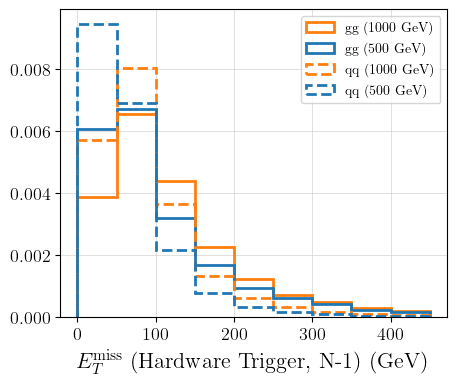

In [30]:
bins=np.arange(0.,500.,50.)

for label,df_g in df.groupby('label'):
    plt.hist(df_g[L1metStr],label=label,bins=bins,histtype='step',
             density=True,color=colorsDict[label],linestyle=linesDict[label],
             linewidth=2)

# plt.yscale('log')
plt.xlabel(L1metStr)
plt.legend()
plt.show()

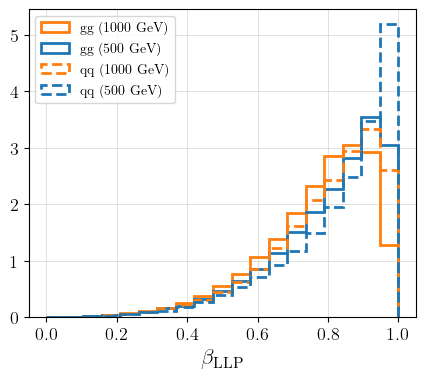

In [33]:
bins=np.linspace(0.,1.,20)

for label,df_g in df.groupby('label'):
   plt.hist(df_g[betaLLPStr],label=label,bins=bins,histtype='step',
             density=True,color=colorsDict[label],linestyle=linesDict[label],
             linewidth=2)

# plt.yscale('log')
plt.xlabel(betaLLPStr)
plt.legend()
plt.show()